In [22]:
!pip install biopython

In [23]:
from Bio import Entrez, SeqIO
from Bio.SeqUtils import gc_fraction
print("Biopython imported successfully!")
print(f"Biopython version: {__import__('Bio').__version__}")

Biopython imported successfully!
Biopython version: 1.86


In [24]:
from Bio import Entrez, SeqIO


Entrez.email = "kvaishali002004@gmail.com"

# fetch the human BRCA1 mRNA sequence
accession = "NM_007294"

print(f"Fetching sequence: {accession} from NCBI...")

handle = Entrez.efetch(
    db="nucleotide",      # which database to search
    id=accession,         # accession number
    rettype="fasta",      # format to return
    retmode="text"        # text mode
)

record = SeqIO.read(handle, "fasta")
handle.close()

print(f"\nID          : {record.id}")
print(f"Description : {record.description[:80]}...")
print(f"Length      : {len(record.seq)} bases")
print(f"First 60bp  : {record.seq[:60]}")

Fetching sequence: NM_007294 from NCBI...

ID          : NM_007294.4
Description : NM_007294.4 Homo sapiens BRCA1 DNA repair associated (BRCA1), transcript variant...
Length      : 7088 bases
First 60bp  : GCTGAGACTTCCTGGACGGGGGACAGGCTGTGGGGTTTCTCAGATAACTGGGCCCCTGCG


In [25]:
from Bio.SeqUtils import gc_fraction

seq = record.seq

# basic stats
length     = len(seq)
gc_content = gc_fraction(seq) * 100
at_content = 100 - gc_content

# base counts
count_a = seq.count('A')
count_t = seq.count('T')
count_g = seq.count('G')
count_c = seq.count('C')

print("===== Sequence Analysis =====")
print(f"Accession   : {record.id}")
print(f"Length      : {length} bases")
print(f"GC Content  : {gc_content:.2f}%")
print(f"AT Content  : {at_content:.2f}%")
print(f"\nBase Counts:")
print(f"  A : {count_a} ({100*count_a/length:.2f}%)")
print(f"  T : {count_t} ({100*count_t/length:.2f}%)")
print(f"  G : {count_g} ({100*count_g/length:.2f}%)")
print(f"  C : {count_c} ({100*count_c/length:.2f}%)")

===== Sequence Analysis =====
Accession   : NM_007294.4
Length      : 7088 bases
GC Content  : 41.77%
AT Content  : 58.23%

Base Counts:
  A : 2368 (33.41%)
  T : 1759 (24.82%)
  G : 1585 (22.36%)
  C : 1376 (19.41%)


In [26]:
import pandas as pd
from Bio import Entrez, SeqIO
from Bio.SeqUtils import gc_fraction
import time

Entrez.email = "kvaishali002004@gmail.com"

# list of accessions to analyze
accessions = {
    "NM_007294" : "BRCA1 - breast cancer gene",
    "NM_000546" : "TP53  - tumor suppressor",
    "NM_005228" : "EGFR  - epidermal growth factor"
}

results = []

for accession, description in accessions.items():
    print(f"Fetching {accession} ({description})...")

    handle = Entrez.efetch(
        db="nucleotide",
        id=accession,
        rettype="fasta",
        retmode="text"
    )
    record = SeqIO.read(handle, "fasta")
    handle.close()

    seq    = record.seq
    length = len(seq)
    gc     = gc_fraction(seq) * 100

    results.append({
        "Accession"   : record.id,
        "Gene"        : description,
        "Length"      : length,
        "GC%"         : round(gc, 2),
        "AT%"         : round(100 - gc, 2),
        "A_count"     : seq.count('A'),
        "T_count"     : seq.count('T'),
        "G_count"     : seq.count('G'),
        "C_count"     : seq.count('C')
    })

    time.sleep(0.5)  # be polite to NCBI - don't hammer their server

# create dataframe
df = pd.DataFrame(results)
print("\n===== Multi-Gene Analysis =====")
print(df.to_string(index=False))

# save to CSV
df.to_csv("gene_analysis.csv", index=False)
print("\nSaved to gene_analysis.csv ")

Fetching NM_007294 (BRCA1 - breast cancer gene)...
Fetching NM_000546 (TP53  - tumor suppressor)...
Fetching NM_005228 (EGFR  - epidermal growth factor)...

===== Multi-Gene Analysis =====
  Accession                            Gene  Length   GC%   AT%  A_count  T_count  G_count  C_count
NM_007294.4      BRCA1 - breast cancer gene    7088 41.77 58.23     2368     1759     1585     1376
NM_000546.6        TP53  - tumor suppressor    2512 53.38 46.62      532      639      621      720
NM_005228.5 EGFR  - epidermal growth factor    9905 47.78 52.22     2736     2436     2282     2451

Saved to gene_analysis.csv 


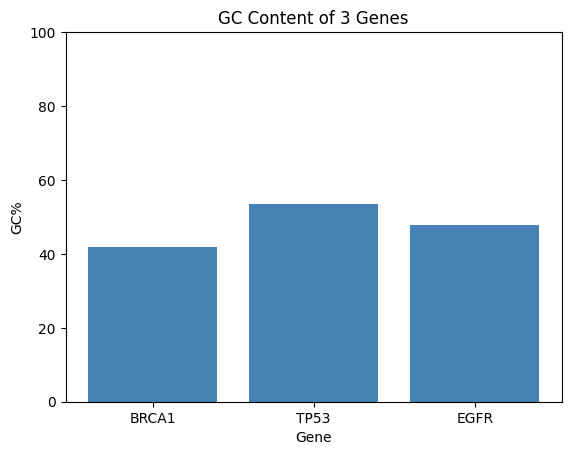

In [27]:
import matplotlib.pyplot as plt

# data
genes = ['BRCA1', 'TP53', 'EGFR']
gc    = [41.77, 53.38, 47.78]

# plot
plt.bar(genes, gc, color='steelblue')
plt.title('GC Content of 3 Genes')
plt.xlabel('Gene')
plt.ylabel('GC%')
plt.ylim(0, 100)
plt.savefig('gene_analysis.png')
plt.show()